In [35]:
df_train = pd.read_csv('/content/train_data_merged.csv', encoding='utf-8')
df_test = pd.read_csv('/content/test_data_merged.csv', encoding='utf-8')

df_train['Success/Failure'] = np.where(df_train['dd10 CM Content'] >= 70, 1, 0)
df_test['Success/Failure'] = np.where(df_test['dd10 CM Content'] >= 70, 1, 0)

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

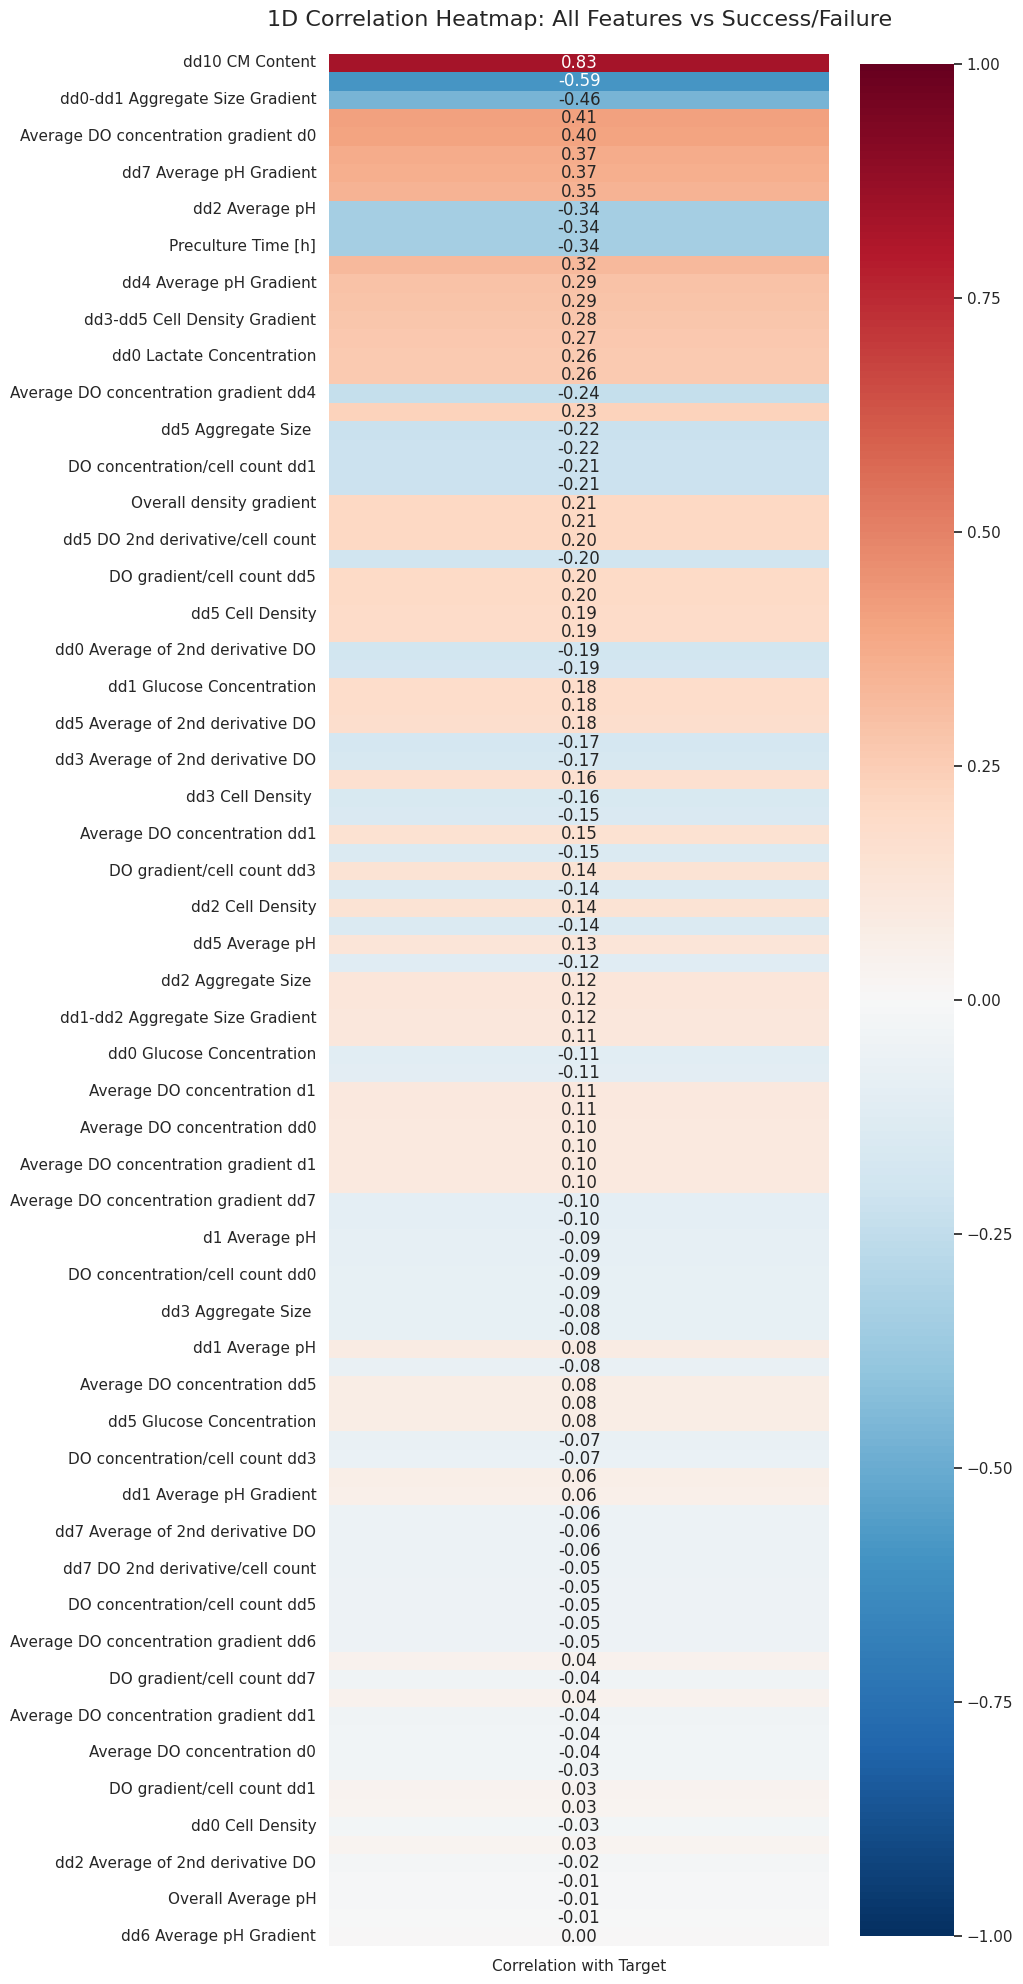

In [36]:
# 수치형 컬럼 상관관계 계산
numeric_df = df_train.select_dtypes(include=[np.number])

correlations = numeric_df.corr()['Success/Failure'].drop('Success/Failure')
correlations_sorted = correlations.reindex(correlations.abs().sort_values(ascending=False).index)

# 히트맵 시각화
plt.figure(figsize=(10, 20))
sns.heatmap(correlations_sorted.to_frame(name='Correlation with Target'),
            annot=True,
            cmap='RdBu_r',
            fmt=".2f",
            vmin=-1, vmax=1)
plt.title("1D Correlation Heatmap: All Features vs Success/Failure", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

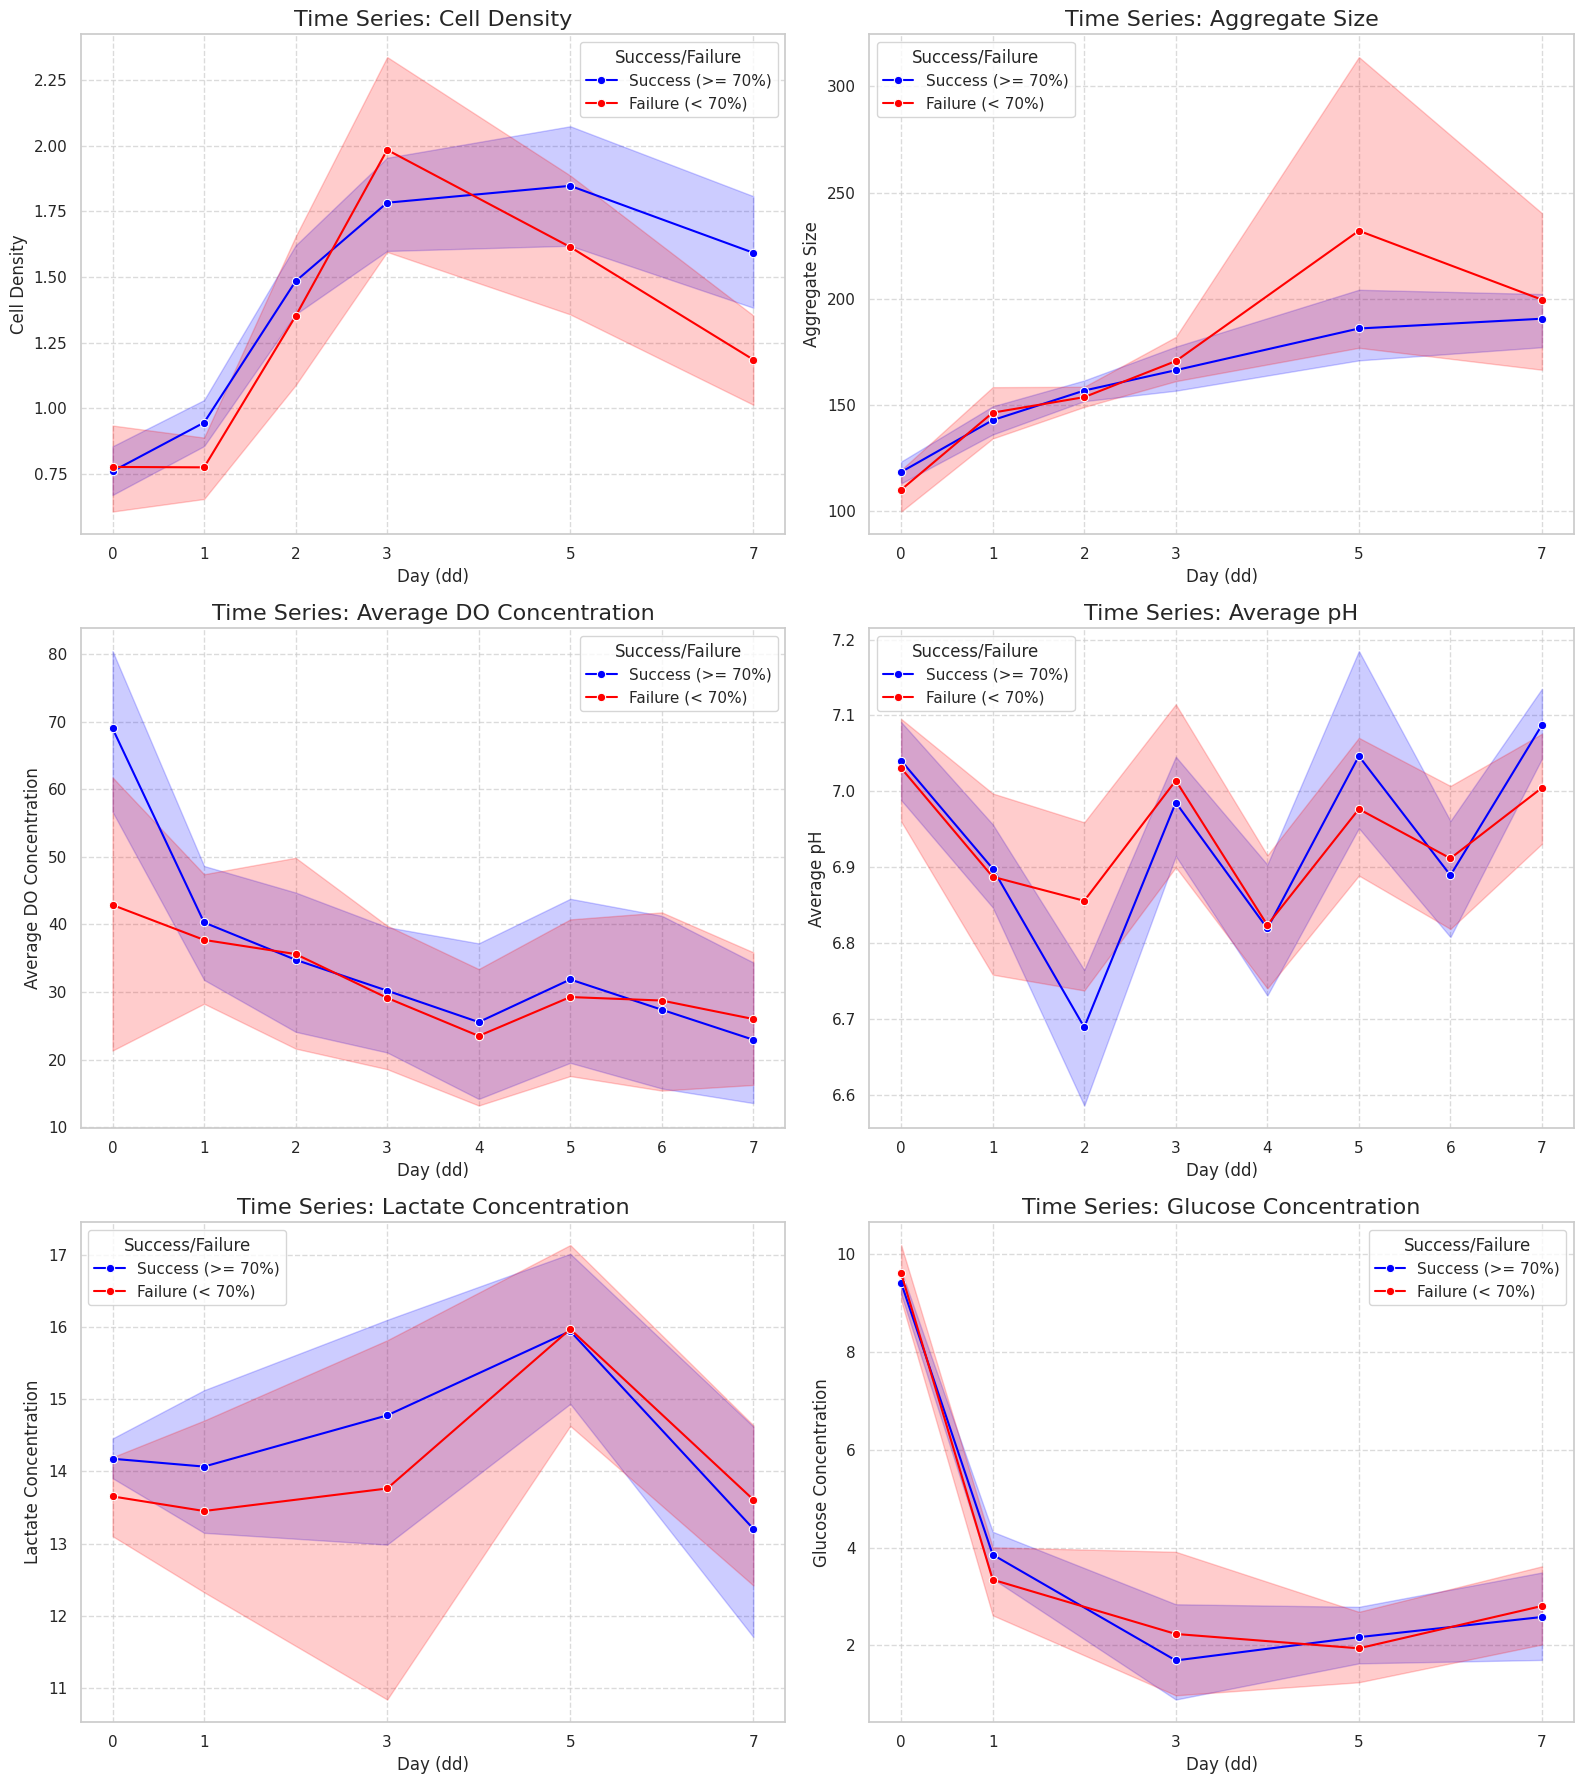

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# 데이터 로드 및 타겟 생성
df = pd.read_csv('/content/train_data_merged.csv', encoding='utf-8')
df['Success/Failure'] = np.where(df['dd10 CM Content'] >= 70, 'Success (>= 70%)', 'Failure (< 70%)')

# 지표별 시계열 데이터 추출 함수
def extract_ts_data(df, base_metric):
    cols = []
    for c in df.columns:
        if base_metric in c and 'Gradient' not in c and 'derivative' not in c and 'count' not in c:
            if re.search(r'\b(d|dd)\d+\b', c):
                cols.append(c)

    if not cols:
        return pd.DataFrame()

    # Long format 변환
    melted = df[['Success/Failure'] + cols].melt(id_vars=['Success/Failure'],
                                                 var_name='Metric',
                                                 value_name='Value')

    def get_day(col_name):
        match = re.search(r'\b(?:d|dd)(\d+)\b', col_name)
        if match:
            return int(match.group(1))
        return np.nan

    melted['Day'] = melted['Metric'].apply(get_day)
    melted = melted.dropna(subset=['Day', 'Value'])
    return melted

# 시각화할 주요 지표
metrics_map = {
    'Cell Density': 'Cell Density',
    'Aggregate Size': 'Aggregate Size',
    'Average DO concentration': 'Average DO Concentration',
    'Average pH': 'Average pH',
    'Lactate Concentration': 'Lactate Concentration',
    'Glucose Concentration': 'Glucose Concentration'
}

# 지표별 시계열 시각화
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for i, (metric_key, metric_title) in enumerate(metrics_map.items()):
    ts_df = extract_ts_data(df, metric_key)

    if not ts_df.empty:
        sns.lineplot(data=ts_df,
                     x='Day',
                     y='Value',
                     hue='Success/Failure',
                     marker='o',
                     ax=axes[i],
                     err_style='band',
                     palette={'Success (>= 70%)': 'blue', 'Failure (< 70%)': 'red'})

        axes[i].set_title(f'Time Series: {metric_title}', fontsize=16)
        axes[i].set_xlabel('Day (dd)', fontsize=12)
        axes[i].set_ylabel(metric_title, fontsize=12)
        axes[i].set_xticks(sorted(ts_df['Day'].unique()))
        axes[i].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
plt.close()

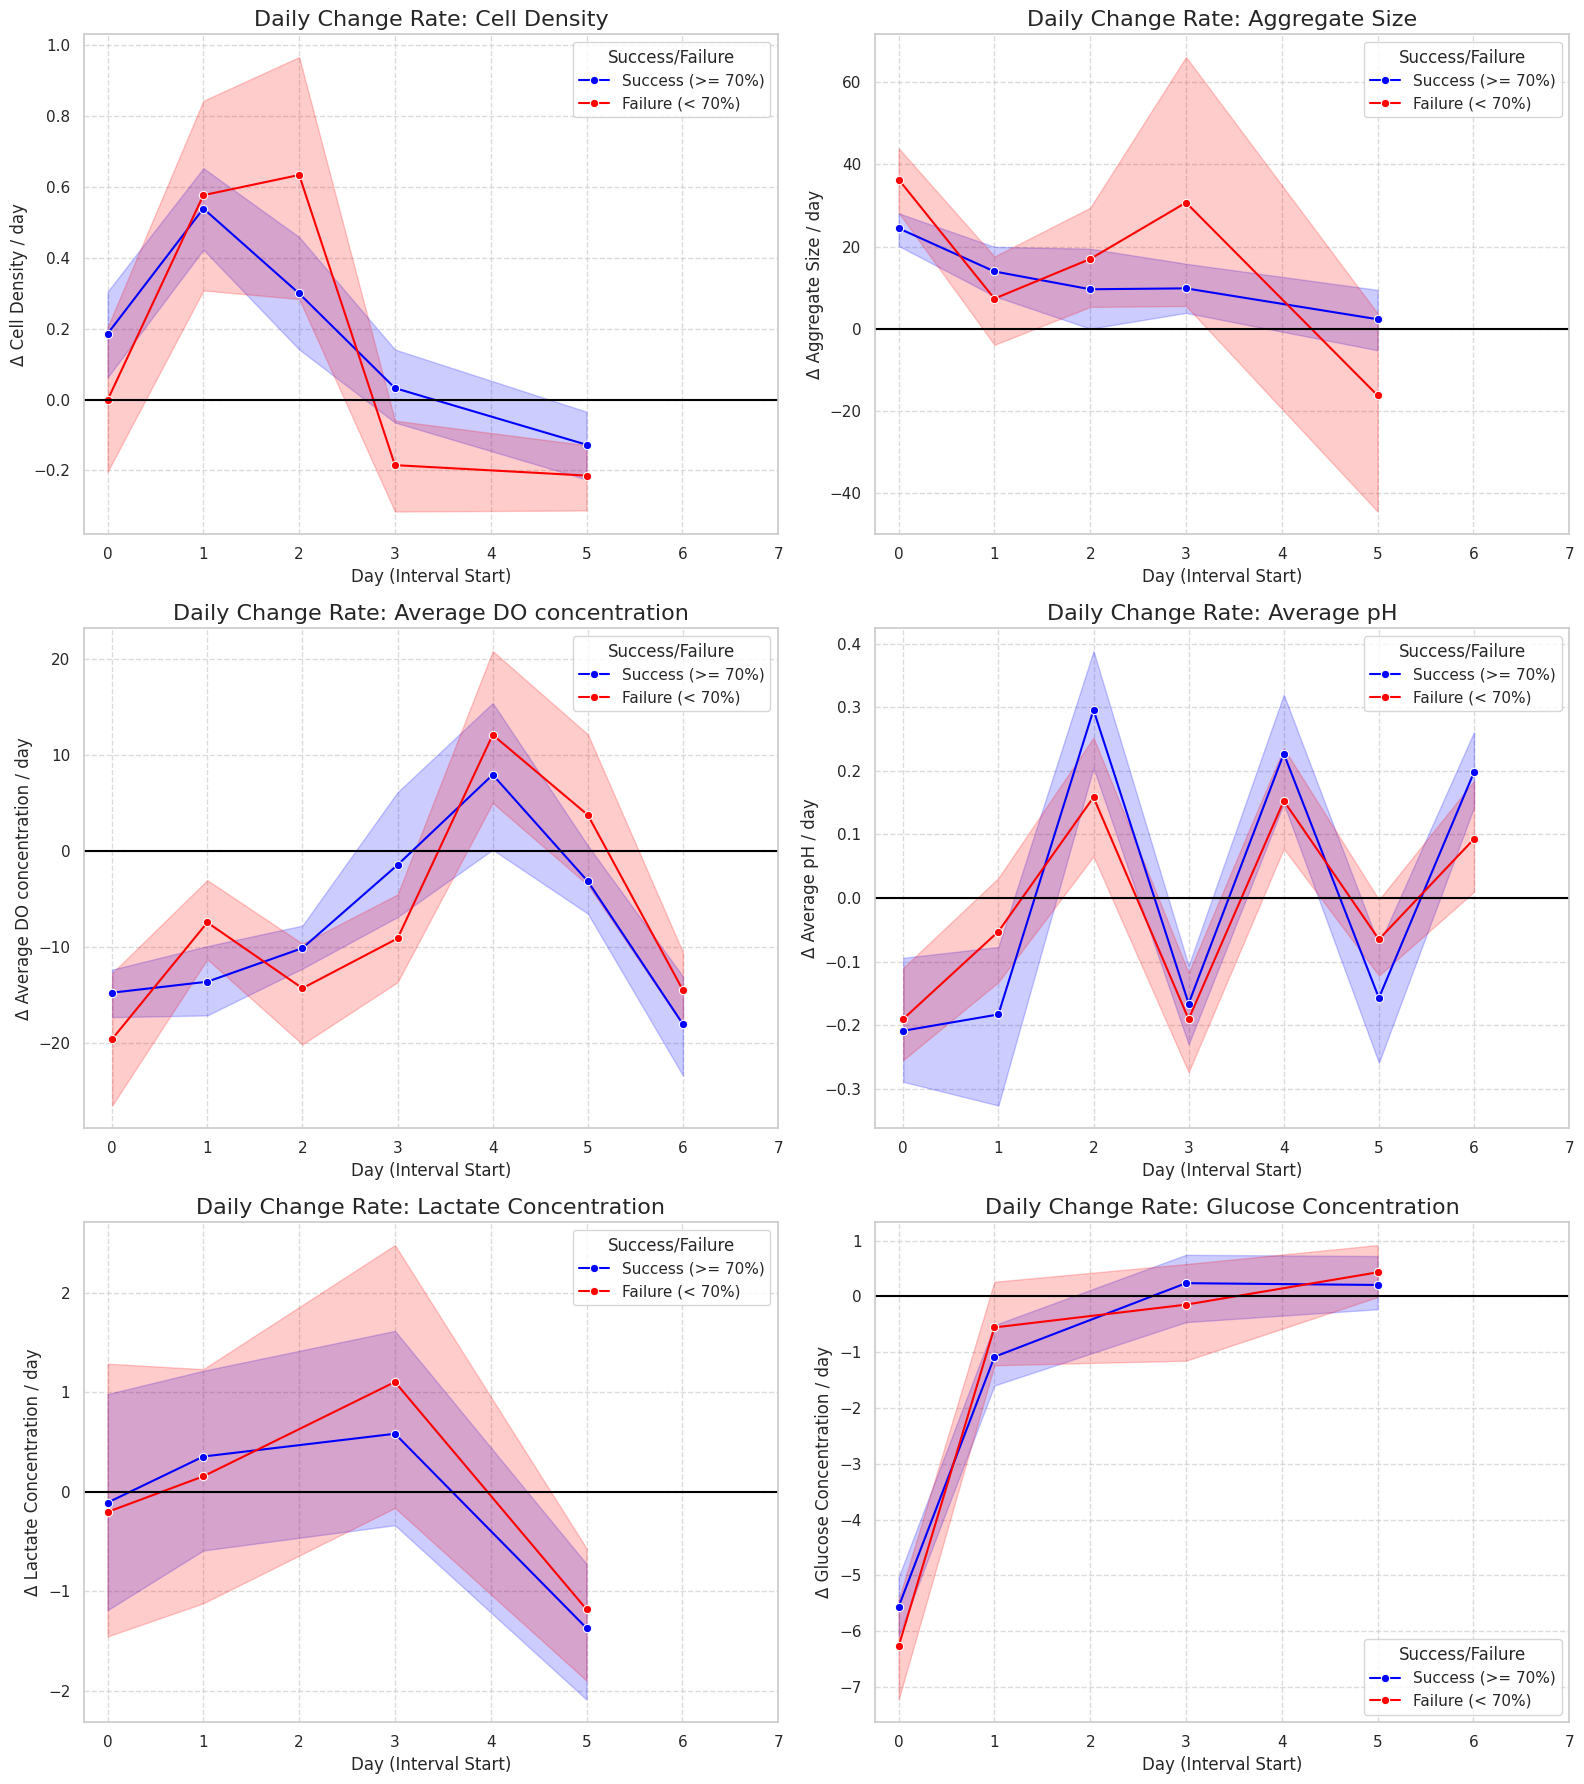

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# 데이터 로드 및 타겟 생성
df = pd.read_csv('/content/train_data_merged.csv', encoding='utf-8')
df['Success/Failure'] = np.where(df['dd10 CM Content'] >= 70, 'Success (>= 70%)', 'Failure (< 70%)')

# 지표별 측정 일자
metrics_days = {
    'Cell Density': [0, 1, 2, 3, 5, 7],
    'Aggregate Size': [0, 1, 2, 3, 5, 7],
    'Average DO concentration': [0, 1, 2, 3, 4, 5, 6, 7],
    'Average pH': [0, 1, 2, 3, 4, 5, 6, 7],
    'Lactate Concentration': [0, 1, 3, 5, 7],
    'Glucose Concentration': [0, 1, 3, 5, 7]
}

# 특정 일자의 컬럼명 탐색 함수
def get_col_name(df, metric, day):
    for c in df.columns:
        if metric in c and 'Gradient' not in c and 'derivative' not in c and 'count' not in c:
            if re.search(rf'\b(d|dd){day}\b', c):
                return c
    return None

# 하루당 변화율 계산
plot_data_list = []

for metric, days in metrics_days.items():
    for i in range(len(days) - 1):
        d_start = days[i]
        d_end = days[i+1]

        c_start = get_col_name(df, metric, d_start)
        c_end = get_col_name(df, metric, d_end)

        if c_start and c_end:
            day_diff = d_end - d_start
            gradient_vals = (df[c_end] - df[c_start]) / day_diff

            temp_df = pd.DataFrame({
                'Success/Failure': df['Success/Failure'],
                'Metric': metric,
                'Start_Day': d_start,
                'Gradient_per_Day': gradient_vals
            })
            plot_data_list.append(temp_df)

final_gradient_df = pd.concat(plot_data_list, ignore_index=True)

# 변화율 시각화
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for i, metric in enumerate(metrics_days.keys()):
    subset = final_gradient_df[final_gradient_df['Metric'] == metric]

    sns.lineplot(data=subset,
                 x='Start_Day',
                 y='Gradient_per_Day',
                 hue='Success/Failure',
                 marker='o',
                 ax=axes[i],
                 err_style='band',
                 palette={'Success (>= 70%)': 'blue', 'Failure (< 70%)': 'red'})

    axes[i].set_title(f'Daily Change Rate: {metric}', fontsize=16)
    axes[i].set_xlabel('Day (Interval Start)', fontsize=12)
    axes[i].set_ylabel(f'Δ {metric} / day', fontsize=12)
    axes[i].set_xticks(range(8))
    axes[i].axhline(0, color='black', linewidth=1.5, linestyle='-')
    axes[i].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
plt.close()

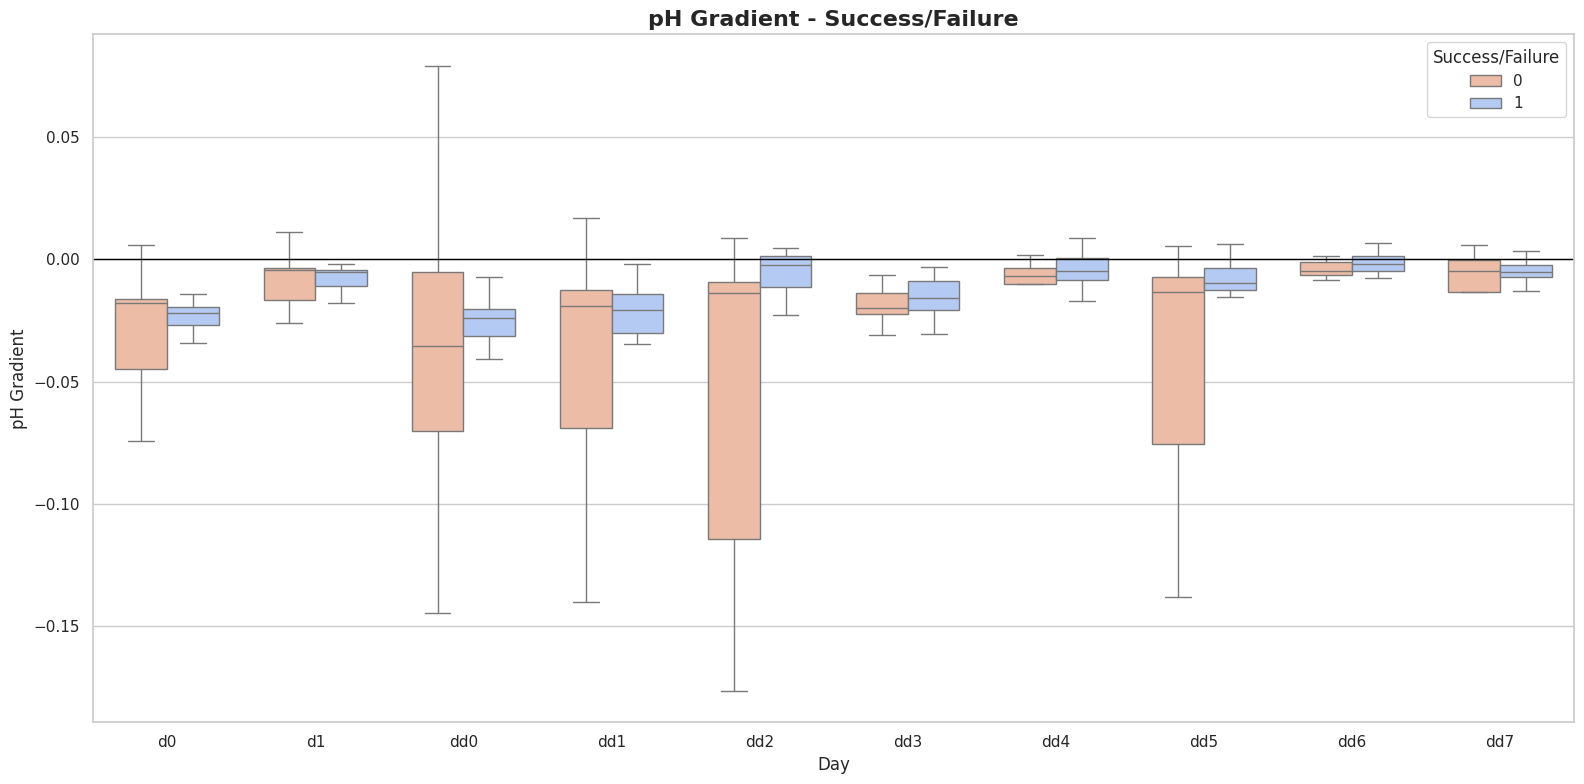

In [39]:
# pH Gradient 박스플롯
gradient_cols = [
    'd0 Average pH Gradient', 'd1 Average pH Gradient',
    'dd0 Average pH Gradient', 'dd1 Average pH Gradient',
    'dd2 Average pH Gradient', 'dd3 Average pH Gradient',
    'dd4 Average pH Gradient', 'dd5 Average pH Gradient',
    'dd6 Average pH Gradient', 'dd7 Average pH Gradient'
]

# Long format 변환
df_melt = pd.melt(df_train,
                  id_vars=['Success/Failure'],
                  value_vars=gradient_cols,
                  var_name='Day',
                  value_name='pH Gradient')
df_melt['Day'] = df_melt['Day'].str.replace(' Average pH Gradient', '')

# 시각화
plt.figure(figsize=(16, 8))
sns.set_theme(style="whitegrid")
sns.boxplot(data=df_melt, x='Day', y='pH Gradient', hue='Success/Failure',
            palette='coolwarm_r', showfliers=False, width=0.7, boxprops={'alpha':1})
plt.title('pH Gradient - Success/Failure', fontsize=16, fontweight='bold')
plt.ylabel('pH Gradient', fontsize=12)
plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.tight_layout()
plt.show()

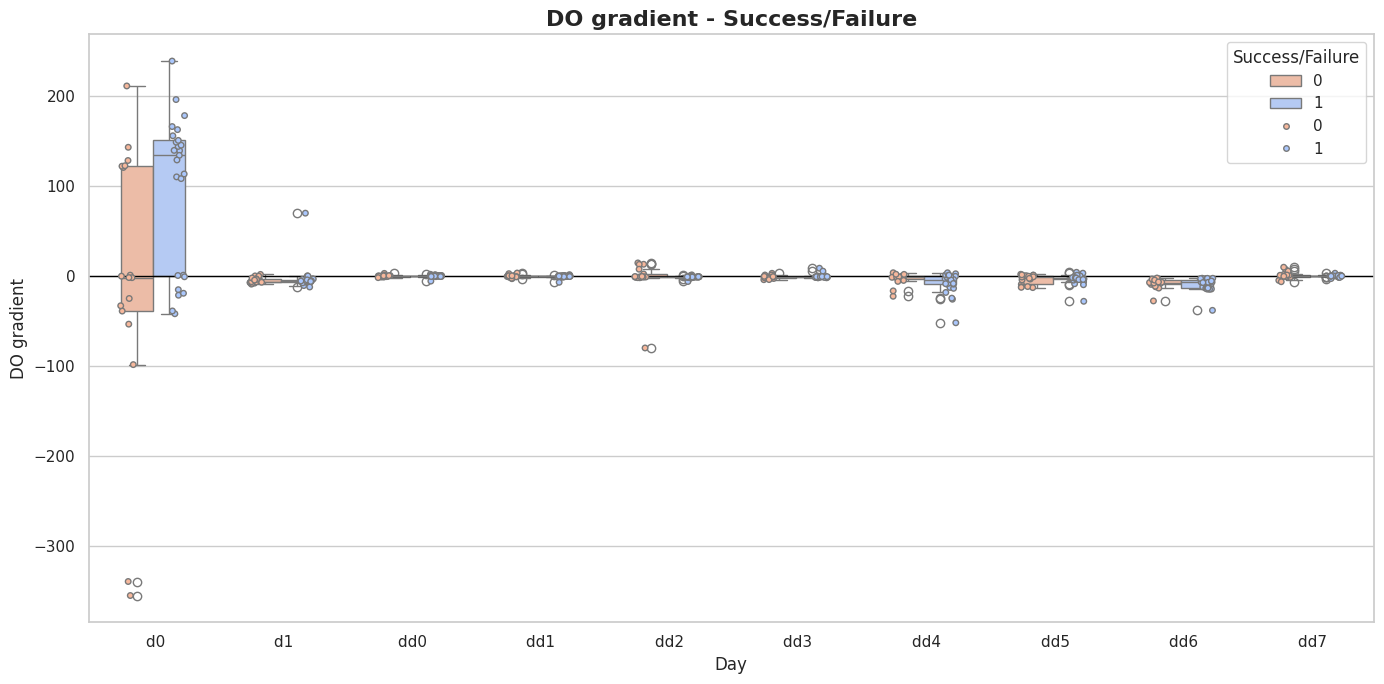

In [40]:
# DO Gradient 박스플롯
do_cols = [
    "Average DO concentration gradient d0", "Average DO concentration gradient d1",
    "Average DO concentration gradient dd0", "Average DO concentration gradient dd1",
    "Average DO concentration gradient dd2", "Average DO concentration gradient dd3",
    "Average DO concentration gradient dd4", "Average DO concentration gradient dd5",
    "Average DO concentration gradient dd6", "Average DO concentration gradient dd7"
]

# Long format 변환
df_melt = pd.melt(df_train,
                  id_vars=['Success/Failure'],
                  value_vars=do_cols,
                  var_name='Day',
                  value_name='DO 2nd Derivative')
df_melt['Day'] = df_melt['Day'].str.replace('Average DO concentration gradient', '')

# 시각화
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")
sns.boxplot(data=df_melt, x='Day', y='DO 2nd Derivative', hue='Success/Failure',
            palette='coolwarm_r', showfliers=True, width=0.5, boxprops={'alpha':1})
sns.stripplot(data=df_melt, x='Day', y='DO 2nd Derivative', hue='Success/Failure',
              palette='coolwarm_r', dodge=True, alpha=1, size=4, linewidth=1)
plt.title('DO gradient - Success/Failure', fontsize=16, fontweight='bold')
plt.ylabel('DO gradient', fontsize=12)
plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.tight_layout()
plt.show()

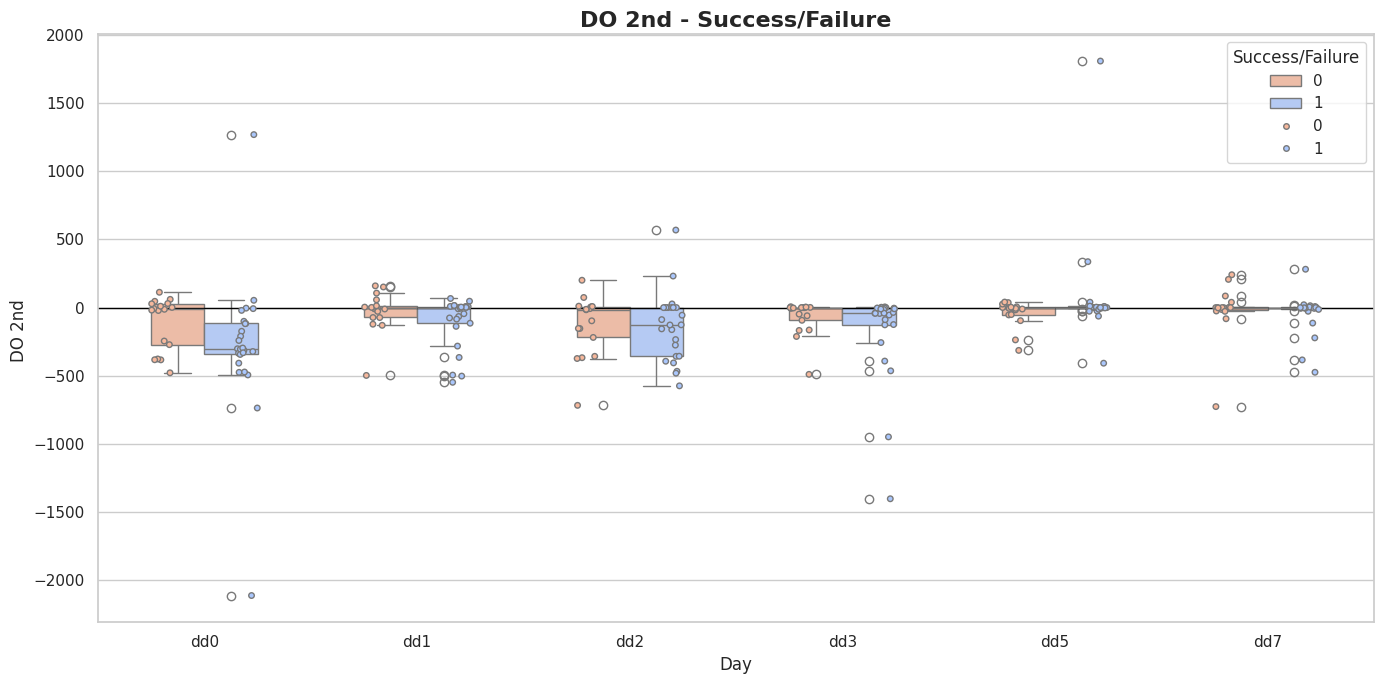

In [41]:
# DO 이계도함수 박스플롯
do_2nd_deriv_cols = [
    "dd0 Average of 2nd derivative DO", "dd1 Average of 2nd derivative DO",
    "dd2 Average of 2nd derivative DO", "dd3 Average of 2nd derivative DO",
    "dd5 Average of 2nd derivative DO", "dd7 Average of 2nd derivative DO"
]

# Long format 변환
df_melt = pd.melt(df_train,
                  id_vars=['Success/Failure'],
                  value_vars=do_2nd_deriv_cols,
                  var_name='Day',
                  value_name='DO 2nd Derivative')
df_melt['Day'] = df_melt['Day'].str.replace(' Average of 2nd derivative DO', '')

# 시각화
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")
sns.boxplot(data=df_melt, x='Day', y='DO 2nd Derivative', hue='Success/Failure',
            palette='coolwarm_r', showfliers=True, width=0.5, boxprops={'alpha':1})
sns.stripplot(data=df_melt, x='Day', y='DO 2nd Derivative', hue='Success/Failure',
              palette='coolwarm_r', dodge=True, alpha=1, size=4, linewidth=1)
plt.title('DO 2nd - Success/Failure', fontsize=16, fontweight='bold')
plt.ylabel('DO 2nd ', fontsize=12)
plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3867/2342923613.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


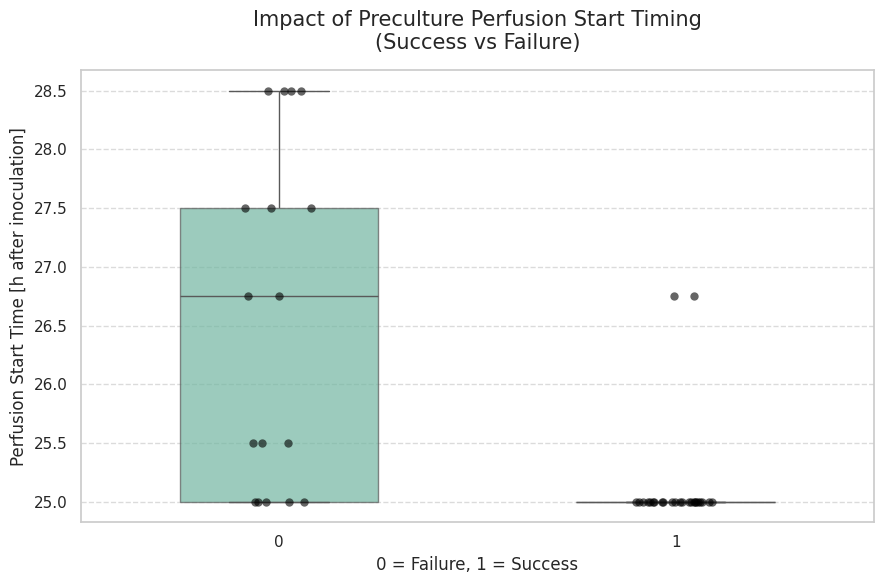

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 데이터 로드 및 타겟 생성
df = pd.read_csv('/content/train_data_merged.csv', encoding='utf-8')
df['Success/Failure'] = np.where(df['dd10 CM Content'] >= 70, 1, 0)

feature_col = 'Start Preculture Perfusion [h after inoc] d1-d2'
plot_data = df[['Success/Failure', feature_col]].dropna()

# 박스플롯 + 산점도 시각화
plt.figure(figsize=(9, 6))
sns.boxplot(
    data=plot_data,
    x='Success/Failure',
    y=feature_col,
    palette='Set2',
    showfliers=False,
    width=0.5,
    boxprops={'alpha': 0.7}
)
sns.stripplot(
    data=plot_data,
    x='Success/Failure',
    y=feature_col,
    color='black',
    alpha=0.6,
    jitter=True,
    size=6
)
plt.title('Impact of Preculture Perfusion Start Timing\n(Success vs Failure)', fontsize=15, pad=15)
plt.xlabel('0 = Failure, 1 = Success', fontsize=12)
plt.ylabel('Perfusion Start Time [h after inoculation]', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

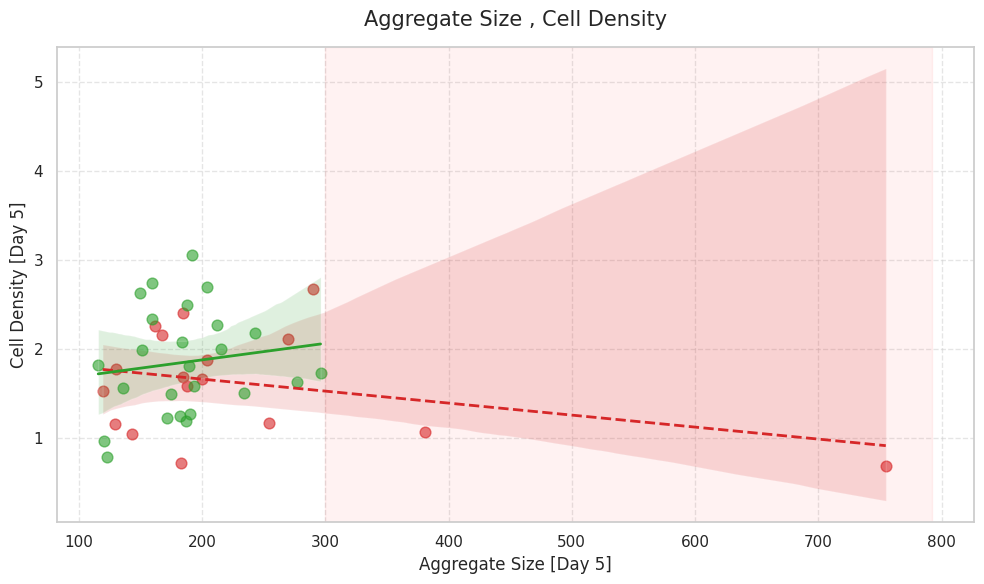

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

col_size = 'dd5 Aggregate Size '
col_density = 'dd5 Cell Density'

plot_data = df[['Success/Failure', col_size, col_density]].dropna()

# 그룹별 피어슨 상관계수 계산
group_s = plot_data[plot_data['Success/Failure'] == 1]
group_f = plot_data[plot_data['Success/Failure'] == 0]
corr_s, p_s = stats.pearsonr(group_s[col_size], group_s[col_density])
corr_f, p_f = stats.pearsonr(group_f[col_size], group_f[col_density])

# 산점도 + 회귀선 시각화
plt.figure(figsize=(10, 6))
sns.regplot(
    data=group_f,
    x=col_size,
    y=col_density,
    color='#d62728',
    label=f'Failure (Corr: {corr_f:.3f})',
    scatter_kws={'alpha':0.6, 's':60},
    line_kws={'linewidth':2, 'linestyle': '--'}
)
sns.regplot(
    data=group_s,
    x=col_size,
    y=col_density,
    color='#2ca02c',
    label=f'Success (Corr: {corr_s:.3f})',
    scatter_kws={'alpha':0.6, 's':60},
    line_kws={'linewidth':2}
)
plt.title('Aggregate Size , Cell Density', fontsize=15, pad=15)
plt.xlabel('Aggregate Size [Day 5]', fontsize=12)
plt.ylabel('Cell Density [Day 5]', fontsize=12)
plt.axvspan(xmin=300, xmax=plot_data[col_size].max() * 1.05,
            color='red', alpha=0.05, label='Danger Zone (Overgrown & Dying)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()